## Descripción del Proyecto

El objetivo de este proyecto es desarrollar y evaluar distintos modelos de clasificación capaces de predecir si un usuario hará clic en un anuncio publicitario digital.

Se aplicaron técnicas de análisis exploratorio de datos, limpieza, preprocesamiento, entrenamiento de modelos y evaluación utilizando diferentes métricas de desempeño.


In [38]:
## importacion de  librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [39]:
# descargar el dataset

data = pd.read_csv(r'C:\Users\chuch\Documents\espy\modelos de clasificacion\publicidad.csv')
data.head()

,Tiempo_en_el_sitio,Edad,Ingresos_de_la_zona,Uso_de_Internet,Sexo,Clic_en_el_anuncio
0,68.95,35,61833.90,256.09,F,0
1,80.23,31,68441.85,193.77,M,0
2,69.47,26,59785.94,236.50,F,0
3,74.15,29,54806.18,245.89,M,0
4,68.37,35,73889.99,225.58,F,0


Descripción del Dataset

El dataset contiene información relacionada con usuarios y su comportamiento frente a anuncios publicitarios.

Variables principales:
Tiempo en el sitio
Edad
Ingreso de la zona
Uso de internet
Sexo
Clic en el anuncio (Variable objetivo)

In [40]:
data.shape

(1000, 6)

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Tiempo_en_el_sitio   1000 non-null   float64
 1   Edad                 1000 non-null   int64  
 2   Ingresos_de_la_zona  1000 non-null   float64
 3   Uso_de_Internet      1000 non-null   float64
 4   Sexo                 1000 non-null   object 
 5   Clic_en_el_anuncio   1000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 47.0+ KB


In [42]:
# Checando los valores nulos
valores_nulos = data.isnull().sum()
print('Valores nulos en cada columna:\n', valores_nulos)

Valores nulos en cada columna:
 Tiempo_en_el_sitio     0
Edad                   0
Ingresos_de_la_zona    0
Uso_de_Internet        0
Sexo                   0
Clic_en_el_anuncio     0
dtype: int64


In [43]:
def fillna_cuantitativas(df):
    df = df.copy()  # evitar modificar el original
    
    cols_num = df.select_dtypes(include='number').columns
    
    df[cols_num] = df[cols_num].apply(lambda x: x.fillna(x.mean()))
    
    return df

In [44]:
data = fillna_cuantitativas(data)

In [45]:
# Drop duplicates si hay alguno
data.drop_duplicates(inplace=True)

In [46]:
#Checando el tipo de datos ahora de nuevo
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Tiempo_en_el_sitio   1000 non-null   float64
 1   Edad                 1000 non-null   int64  
 2   Ingresos_de_la_zona  1000 non-null   float64
 3   Uso_de_Internet      1000 non-null   float64
 4   Sexo                 1000 non-null   object 
 5   Clic_en_el_anuncio   1000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 47.0+ KB


## Exploracion de datos

In [47]:
data.describe()

,Tiempo_en_el_sitio,Edad,Ingresos_de_la_zona,Uso_de_Internet,Clic_en_el_anuncio
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.00000


## Estadística descriptiva

In [48]:
def resumen_estadistico (data, columnas='Cuantitativo'):
    
    """
    Calcula estadísticas descriptivas para múltiples columnas cuantitativas.
      Retorna:
    DataFrame con estadísticas descriptivas para cada columna especificada."""

    if columnas == 'Cuantitativo':
        columnas = data.select_dtypes(include=np.number).columns
    
    resumen = pd.DataFrame({
        'Media': data[columnas].mean(),
        'Mediana': data[columnas].median(),
        'Moda': data[columnas].mode().iloc[0] if not data[columnas].mode().empty else np.nan,
        'Min': data[columnas].min(),
        'Max': data[columnas].max(),
        'Varianza': data[columnas].var(),
        'Desv_Estandar': data[columnas].std(),
        'Q1_25%': data[columnas].quantile(0.25),
        'Q3_75%': data[columnas].quantile(0.75)
    })
    
    resumen['Rango'] = resumen['Max'] - resumen['Min']
    
    return resumen.round(4)

In [49]:
resumen_estadistico(data)

,Media,Mediana,Moda,Min,Max,Varianza,Desv_Estandar,Q1_25%,Q3_75%,Rango
Tiempo_en_el_sitio,65.0002,68.215,62.26,32.60,91.43,2.513371e+02,15.8536,51.3600,78.5475,58.83
Edad,36.0090,35.000,31.00,19.00,61.00,7.718610e+01,8.7856,29.0000,42.0000,42.00
Ingresos_de_la_zona,55000.0001,57012.300,13996.50,13996.50,79484.80,1.799524e+08,13414.6340,47031.8025,65470.6350,65488.30
Uso_de_Internet,180.0001,183.130,113.53,104.78,269.96,1.927415e+03,43.9023,138.8300,218.7925,165.18
Clic_en_el_anuncio,0.5000,0.500,0.00,0.00,1.00,2.503000e-01,0.5003,0.0000,1.0000,1.00


In [50]:
cov_matrix = data.cov(numeric_only= True)

print('La covarianza es: \n', cov_matrix)

La covarianza es: 
                      Tiempo_en_el_sitio          Edad  Ingresos_de_la_zona  \
Tiempo_en_el_sitio           251.337095    -46.174146         6.613081e+04   
Edad                         -46.174146     77.186105        -2.152093e+04   
Ingresos_de_la_zona        66130.810908 -21520.925797         1.799524e+08   
Uso_de_Internet              360.991883   -141.634816         1.987625e+05   
Clic_en_el_anuncio            -5.933143      2.164665        -3.195989e+03   

                     Uso_de_Internet  Clic_en_el_anuncio  
Tiempo_en_el_sitio        360.991883           -5.933143  
Edad                     -141.634816            2.164665  
Ingresos_de_la_zona    198762.531533        -3195.989159  
Uso_de_Internet          1927.415396          -17.274094  
Clic_en_el_anuncio        -17.274094            0.250250  


## Relacion entre variables (correlacion)

In [51]:
import sklearn
# Cargar librerias

# Tratamiento de Datos

import pandas as pd
import numpy as np

#Graficos

import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

#Preprocesamiento y Modelo

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV

#Configuracion de nuestro visuales

plt.rcParams['image.cmap'] = 'bwr'
plt.rcParams['savefig.bbox'] = 'tight'
style.use('ggplot') or plt.style.use('ggplot')

#Ignorar las advertencias de paquetes y sus actualizaciones
import warnings
warnings.filterwarnings('ignore')

In [52]:
# Correlacion entre columnas numericas

def matriz_correlacion(corr_mat):
  """ Funcion para Convertir una matriz de correlacion en formato numerica """
  corr_mat = corr_mat.stack().reset_index()
  corr_mat.columns = ['variable 1','variable 2','Correlacion']
  corr_mat = corr_mat.loc[corr_mat['variable 1'] != corr_mat['variable 2'], :]
  corr_mat['Valor Absoluto'] = np.abs(corr_mat['Correlacion'])
  corr_mat = corr_mat.sort_values('Valor Absoluto', ascending = False)

  return(corr_mat)

corr_matrix = data.select_dtypes(include = ['float','int']).corr(method = 'pearson')
matriz_correlacion(corr_matrix).head(20)

,variable 1,variable 2,Correlacion,Valor Absoluto
23,Clic_en_el_anuncio,Uso_de_Internet,-0.786539,0.786539
19,Uso_de_Internet,Clic_en_el_anuncio,-0.786539,0.786539
4,Tiempo_en_el_sitio,Clic_en_el_anuncio,-0.748117,0.748117
20,Clic_en_el_anuncio,Tiempo_en_el_sitio,-0.748117,0.748117
3,Tiempo_en_el_sitio,Uso_de_Internet,0.518658,0.518658
15,Uso_de_Internet,Tiempo_en_el_sitio,0.518658,0.518658
21,Clic_en_el_anuncio,Edad,0.492531,0.492531
9,Edad,Clic_en_el_anuncio,0.492531,0.492531
22,Clic_en_el_anuncio,Ingresos_de_la_zona,-0.476255,0.476255
14,Ingresos_de_la_zona,Clic_en_el_anuncio,-0.476255,0.476255


Variables más influyentes :
Uso_de_Internet (correlación ≈ -0.79) → la más fuerte.
Tiempo_en_el_sitio (correlación ≈ -0.75) → segunda más importante.
Ambas tienen correlación negativa fuerte: a mayor tiempo en el sitio y mayor uso de internet, menos probabilidad de hacer clic en el anuncio.
La Edad también influye positivamente (≈ +0.49): usuarios mayores parecen más propensos a hacer clic.

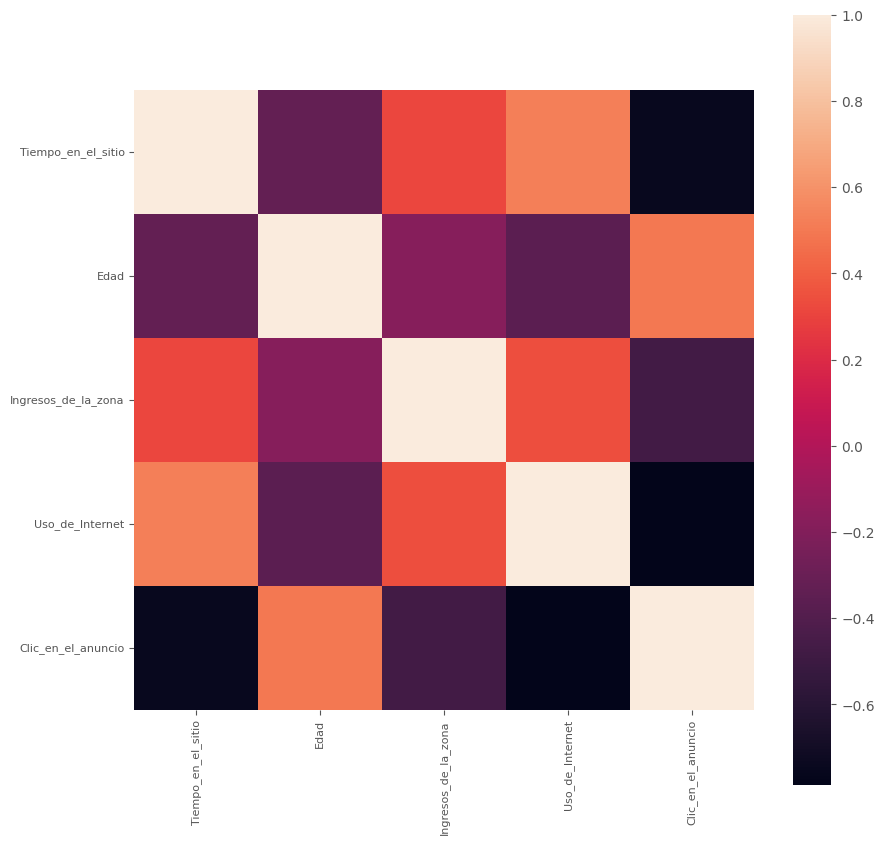

In [53]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (10,10))

sns.heatmap(
    corr_matrix,
    square = True,
    ax = ax)

ax.tick_params(labelsize = 8)

##  valores atipicos

In [54]:
data.columns

Index(['Tiempo_en_el_sitio', 'Edad', 'Ingresos_de_la_zona', 'Uso_de_Internet',
       'Sexo', 'Clic_en_el_anuncio'],
      dtype='object')

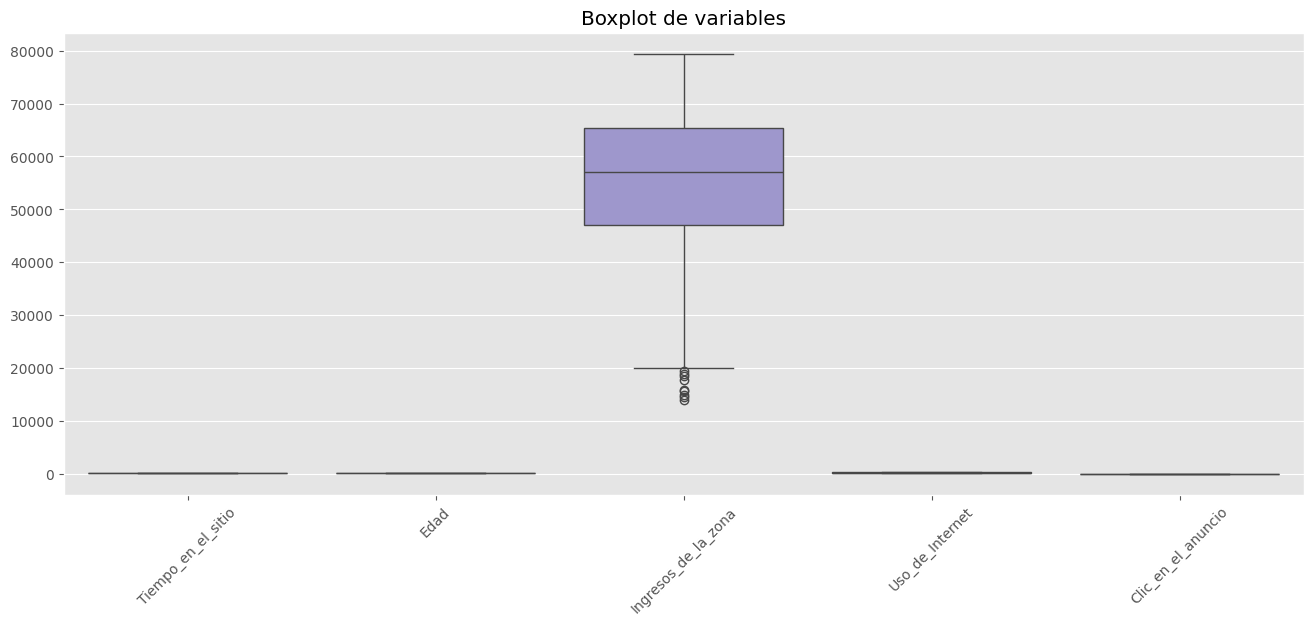

In [55]:
plt.figure(figsize=(16, 6))

sns.boxplot(data=data[['Tiempo_en_el_sitio', 'Edad', 'Ingresos_de_la_zona', 'Uso_de_Internet',
       'Sexo', 'Clic_en_el_anuncio']])

plt.title('Boxplot de variables')
plt.xticks(rotation=45)
plt.show()

In [56]:
# Vamos a buscar los valores atipicos para cada variable

IQR = data.Tiempo_en_el_sitio.quantile(0.75)-data.Tiempo_en_el_sitio.quantile(0.25)
limite_inferior_rainfall = data.Tiempo_en_el_sitio.quantile(0.25) - (IQR * 3)
limite_superior_rainfall = data.Tiempo_en_el_sitio.quantile(0.75) + (IQR * 3)

print('Los valores atipicos de Tiempo_en_el_sitio <{bajo} o > {alto}'.format(bajo = limite_inferior_rainfall, alto = limite_superior_rainfall))

Los valores atipicos de Tiempo_en_el_sitio <-30.2025 o > 160.11


In [57]:
# Vamos a buscar los valores atipicos para cada variable

IQR = data.Ingresos_de_la_zona.quantile(0.75)-data.Ingresos_de_la_zona.quantile(0.25)
limite_inferior_rainfall = data.Ingresos_de_la_zona.quantile(0.25) - (IQR * 3)
limite_superior_rainfall = data.Ingresos_de_la_zona.quantile(0.75) + (IQR * 3)

print('Los valores atipicos de Ingresos_de_la_zona <{bajo} o > {alto}'.format(bajo = limite_inferior_rainfall, alto = limite_superior_rainfall))

Los valores atipicos de Ingresos_de_la_zona <-8284.694999999992 o > 120787.13249999998


In [58]:
# Vamos a buscar los valores atipicos para cada variable

IQR = data.Edad.quantile(0.75)-data.Edad.quantile(0.25)
limite_inferior_rainfall = data.Edad.quantile(0.25) - (IQR * 3)
limite_superior_rainfall = data.Edad.quantile(0.75) + (IQR * 3)

print('Los valores atipicos de Edad <{bajo} o > {alto}'.format(bajo = limite_inferior_rainfall, alto = limite_superior_rainfall))

Los valores atipicos de Edad <-10.0 o > 81.0


In [59]:
# Vamos a buscar los valores atipicos para cada variable

IQR = data.Uso_de_Internet.quantile(0.75)-data.Uso_de_Internet.quantile(0.25)
limite_inferior_rainfall = data.Uso_de_Internet.quantile(0.25) - (IQR * 3)
limite_superior_rainfall = data.Uso_de_Internet.quantile(0.75) + (IQR * 3)

print('Los valores atipicos de Uso_de_Internet <{bajo} o > {alto}'.format(bajo = limite_inferior_rainfall, alto = limite_superior_rainfall))

Los valores atipicos de Uso_de_Internet <-101.05749999999992 o > 458.67999999999995


## Distribucion de clases (prevalencia)

Prevalencia de clases:


,conteo,proporcion
Clase negativa (0: No clic),500,0.5
Clase positiva (1: Clic),500,0.5


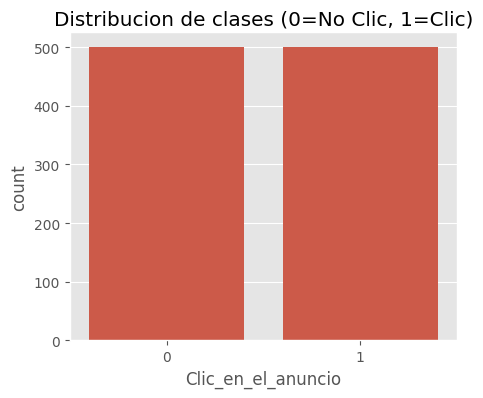

In [60]:
# Distribucion de clases (prevalencia)    
conteo = data['Clic_en_el_anuncio'].value_counts().sort_index()
prevalencia = data['Clic_en_el_anuncio'].value_counts(normalize=True).sort_index()

resumen_clases = pd.DataFrame({
    'conteo': conteo,
    'proporcion': prevalencia
})
resumen_clases.index = ['Clase negativa (0: No clic)', 'Clase positiva (1: Clic)']    #hay un desvalanceo de clases

print('Prevalencia de clases:')
display(resumen_clases)

plt.figure(figsize=(5,4))
sns.countplot(x=data['Clic_en_el_anuncio'])
plt.title('Distribucion de clases (0=No Clic, 1=Clic)')
plt.show()

## Librerias de Machine Learning  y Modelos de clasificación

In [61]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.stats import randint, uniform

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis  #aqui se utiliza el lda y qda (diferente al otro codigo)
from sklearn.naive_bayes import GaussianNB

In [62]:



import pandas as pd #procesamiento datos
import matplotlib.pyplot as plt #Visualizacion de Datos
import seaborn as sns # Visualizaciones estadisticas
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, RobustScaler
from category_encoders import BinaryEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, log_loss, cohen_kappa_score
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [63]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

## Creación de Pipelines para tranformaciones automatizadas y separcacion de las X y la Y

In [64]:
from sklearn.compose import ColumnTransformer
# Target + features
y = data['Clic_en_el_anuncio'].astype(int)

X = data.drop(columns=['Clic_en_el_anuncio'])

# Columnas

columnas_categoricas = X.select_dtypes(
    include=['object']
).columns.tolist()

columnas_numericas = X.select_dtypes(
    exclude=['object']
).columns.tolist()


# Pipeline numérico
transformador_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Pipeline categórico
transformador_categorico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Preprocesador
preprocess = ColumnTransformer(
    transformers=[
        ('numerico', transformador_numerico, columnas_numericas),
        ('categorico', transformador_categorico, columnas_categoricas)
    ]
)

print(columnas_categoricas)
print(columnas_numericas)

['Sexo']
['Tiempo_en_el_sitio', 'Edad', 'Ingresos_de_la_zona', 'Uso_de_Internet']


## Definir modelos

Modelos Implementados

Se entrenaron y compararon múltiples algoritmos de clasificación:

Modelo	
Logistic Regression	
Gaussian Naive Bayes	
Random Forest	
Gradient Boosting	
MLPClassifier	

In [65]:
models = {
    'knn': KNeighborsClassifier(),
    'dt': DecisionTreeClassifier(random_state=42),
    'random_forest': RandomForestClassifier(random_state=42),
    'logistic_regresion': LogisticRegression(max_iter=2000, random_state=42),
    'adaboost': AdaBoostClassifier(random_state=42),
    'xgboost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'gradientboostin': GradientBoostingClassifier(random_state=42),
    'litghxgboot': LGBMClassifier(random_state=42, verbose=-1),
    'mlp': MLPClassifier(max_iter=1200, random_state=42),

    # Nuevos modelos lda, qda y naive bayes
    'lda': LinearDiscriminantAnalysis(),
    'qda': QuadraticDiscriminantAnalysis(),
    'naive_bayes': GaussianNB(),
}

param_spaces = {
    'knn': {
        'model__n_neighbors': randint(3, 35),
        'model__weights': ['uniform', 'distance']
    },

    'dt': {
        'model__max_depth': randint(2, 20),
        'model__min_samples_split': randint(2, 20)
    },

    'random_forest': {
        'model__n_estimators': randint(300, 500),
        'model__max_depth': randint(10, 18),
        'model__min_samples_split': randint(2, 15),
        'model__max_features': ['sqrt', 'log2', None]
    },

    'logistic_regresion': {
        'model__C': uniform(0.5, 2),
        'model__solver': ['lbfgs', 'liblinear'],
        'model__penalty': ['l2']
        
    },

    'adaboost': {
        'model__n_estimators': randint(50, 300),
        'model__learning_rate': uniform(0.01, 1.0)
    },

    'xgboost': {
        'model__n_estimators': randint(80, 400),
        'model__max_depth': randint(4, 6),
        'model__learning_rate': uniform(0.08, 0.15),
        'model__subsample': uniform(0.8, 0.95),
        'model__colsample_bytree': uniform(0.8, 0.8)
    },

    'gradientboostin': {
        'model__n_estimators': randint(80, 300),
        'model__max_depth': randint(31, 63),
        'model__learning_rate': uniform(0.1, 0.3)
    },

    'litghxgboot': {
        'model__n_estimators': randint(80, 300),
        'model__num_leaves': randint(31, 63),
        'model__learning_rate': uniform(0.1, 0.3)
    },

    'mlp': {
        'model__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
        'model__alpha': uniform(1e-5, 1e-2),
        'model__learning_rate_init': uniform(1e-4, 5e-3)
    },

    # Nuevos espacios de hiperparámetros
    #aqui llamo a los nuevos modelos
    'lda': {
        'model__solver': ['svd', 'lsqr', 'eigen']   #solver es para crear esa linea de separacion
    },

    'qda': {
        'model__reg_param': uniform(0.0, 1.0)   #reg_param esel que regula esa linea
    },

    'naive_bayes': {
        'model__var_smoothing': uniform(1e-11, 1e-7)
    }
}

## Entrenamiento y metricas
Metricas incluidas:

Accuracy
Precision clase positiva (1)
Precision clase negativa (0)
Recall (sensibilidad)
Specificity (recall de clase negativa)
F1 score
Balanced Accuracy
ROC AUC

In [66]:
# Tuneo + evaluacion final con varias metricas 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_spaces[name],
        n_iter=50,
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        random_state=42
    )

    search.fit(X,y)
    best_model = search.best_estimator_
    
    y_pred = best_model.predict(X)
    y_prob = best_model.predict_proba(X)[:, 1]

    f1_scores = cross_val_score(best_model, X, y, cv=cv, scoring='f1', n_jobs=-1)
    precision_scores = cross_val_score(best_model, X, y, cv=cv, scoring='precision', n_jobs=-1)
    recall_scores = cross_val_score(best_model, X, y, cv=cv, scoring='recall', n_jobs=-1)
    accuracy_scores = cross_val_score(best_model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    roc_auc_scores = cross_val_score(best_model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

    resultados.append({
        'modelo': name,
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std(),
        'precision_mean': precision_scores.mean(),
        'recall_mean': recall_scores.mean(),
        'accuracy_mean': accuracy_scores.mean(),
        'roc_auc_mean': roc_auc_scores.mean(),
        'cv_error': 1 - f1_scores.mean(),
        'mejores_hiperparametros': str(search.best_params_)
    })

res_df = pd.DataFrame(resultados).sort_values('f1_mean', ascending=False).reset_index(drop=True)
res_df[['modelo', 'f1_mean', 'f1_std', 'precision_mean', 'recall_mean', 'accuracy_mean', 'roc_auc_mean', 'cv_error', 'mejores_hiperparametros']]

,modelo,f1_mean,f1_std,precision_mean,recall_mean,accuracy_mean,roc_auc_mean,cv_error,mejores_hiperparametros
0,mlp,0.969898,0.010926,0.973954,0.966,0.970,0.99104,0.030102,"{'model__alpha': 0.0020894166286818884, 'model..."
1,logistic_regresion,0.968413,0.014312,0.985499,0.952,0.969,0.99092,0.031587,"{'model__C': 1.6973169683940732, 'model__penal..."
2,naive_bayes,0.965937,0.011556,0.968009,0.964,0.966,0.99068,0.034063,{'model__var_smoothing': 3.746401188473625e-08}
3,qda,0.965073,0.014152,0.989448,0.942,0.966,0.99048,0.034927,{'model__reg_param': 0.020584494295802447}
4,random_forest,0.964973,0.008317,0.966055,0.964,0.965,0.98917,0.035027,"{'model__max_depth': 10, 'model__max_features'..."
5,adaboost,0.962932,0.007897,0.966011,0.960,0.963,0.98970,0.037068,"{'model__learning_rate': 0.6086584841970366, '..."
6,knn,0.961785,0.009699,0.993616,0.932,0.963,0.98683,0.038215,"{'model__n_neighbors': 24, 'model__weights': '..."
7,litghxgboot,0.959833,0.011088,0.966006,0.954,0.960,0.98754,0.040167,"{'model__learning_rate': 0.2560204063533432, '..."
8,lda,0.959530,0.011222,0.995699,0.926,0.961,0.99008,0.040470,{'model__solver': 'svd'}
9,dt,0.958707,0.011986,0.963718,0.954,0.959,0.96970,0.041293,"{'model__max_depth': 5, 'model__min_samples_sp..."


In [67]:
print("Mejores hiperparámetros:", search.best_params_)
print("Mejor F1 CV:", search.best_score_.round(4))


Mejores hiperparámetros: {'model__var_smoothing': 3.746401188473625e-08}
Mejor F1 CV: 0.9659


In [68]:
print('predicciones:', y_pred[:10])
print('probabilidades:', y_prob[:10])

predicciones: [0 0 0 0 0 0 0 1 0 0]
probabilidades: [5.70391485e-04 2.65346832e-03 7.44295233e-04 2.69384806e-04
 3.37155223e-03 1.67007704e-02 1.79997080e-03 9.99999686e-01
 5.58371975e-04 5.45517636e-02]


Text(0, 0.5, 'Frecuencia')

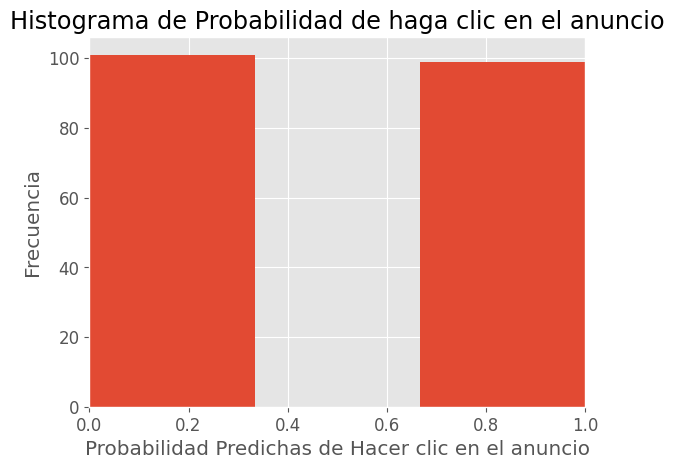

In [80]:
#Plotear el Histograma de las probabilidades de las predicciones

plt.rcParams['font.size'] = 12

plt.hist(y_pred, bins = 3)

plt.title('Histograma de Probabilidad de haga clic en el anuncio')

plt.xlim(0,1)

plt.xlabel('Probabilidad Predichas de Hacer clic en el anuncio')
plt.ylabel('Frecuencia')

In [69]:
# Tuneo + evaluacion final con varias metricas con train_test_split para evaluar en un conjunto de test separado y no solo con validacion cruzada, 
# ademas se agregan nuevas metricas como precision, recall, accuracy, roc_auc y cohen_kappa_score para tener una evaluacion mas completa del modelo. Se incluyen nuevos modelos como LDA, QDA y Naive Bayes con sus respectivos espacios de hiperparametros.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#Tuneo + evaluacion final con varias metricas
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_spaces[name],
        n_iter=12,
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    best_model = search.best_estimator_

    f1_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    precision_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='precision', n_jobs=-1)
    recall_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='recall', n_jobs=-1)
    roc_auc_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    accuracy_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    resultados.append({
        'modelo': name,
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std(),
        'precision_mean': precision_scores.mean(),
        'recall_mean': recall_scores.mean(),
        'accuracy_mean': accuracy_scores.mean(),
        'roc_auc_mean': roc_auc_scores.mean(),
        'cv_error': 1 - f1_scores.mean(),
        'mejores_hiperparametros': str(search.best_params_)
    })

res_df = pd.DataFrame(resultados).sort_values('f1_mean', ascending=False).reset_index(drop=True)
res_df[['modelo', 'f1_mean', 'f1_std', 'precision_mean', 'recall_mean', 'accuracy_mean', 'roc_auc_mean', 'cv_error', 'mejores_hiperparametros']]


,modelo,f1_mean,f1_std,precision_mean,recall_mean,accuracy_mean,roc_auc_mean,cv_error,mejores_hiperparametros
0,mlp,0.968438,0.014381,0.977310,0.9600,0.96875,0.990187,0.031562,"{'model__alpha': 0.009747555188414591, 'model_..."
1,logistic_regresion,0.965519,0.009830,0.984575,0.9475,0.96625,0.989469,0.034481,"{'model__C': 1.6973169683940732, 'model__penal..."
2,qda,0.965354,0.006867,0.989736,0.9425,0.96625,0.989094,0.034646,{'model__reg_param': 0.020584494295802447}
3,naive_bayes,0.963797,0.012979,0.965503,0.9625,0.96375,0.989437,0.036203,{'model__var_smoothing': 3.746401188473625e-08}
4,adaboost,0.962185,0.013340,0.970153,0.9550,0.96250,0.991156,0.037815,"{'model__learning_rate': 0.34370861113902185, ..."
5,knn,0.961268,0.015619,0.989466,0.9350,0.96250,0.985234,0.038732,"{'model__n_neighbors': 13, 'model__weights': '..."
6,xgboost,0.959907,0.010820,0.962980,0.9575,0.96000,0.991000,0.040093,{'model__colsample_bytree': 0.9847150604977193...
7,litghxgboot,0.959827,0.006227,0.965461,0.9550,0.96000,0.991531,0.040173,"{'model__learning_rate': 0.19127267288786132, ..."
8,random_forest,0.958066,0.020004,0.954608,0.9625,0.95750,0.991031,0.041934,"{'model__max_depth': 14, 'model__max_features'..."
9,lda,0.957027,0.013875,0.994658,0.9225,0.95875,0.988125,0.042973,{'model__solver': 'svd'}


In [70]:
#pip install Jinja2

In [71]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    balanced_accuracy_score,
)
from pandas.io.formats.style import Styler
from sklearn.exceptions import UndefinedMetricWarning
import warnings

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

In [72]:
resultados = []
conf_matrices = {}
roc_curvas = {}

for nombre, modelo in models.items():
    pipe = Pipeline(steps=[
        ('prep', preprocess),
        ('model', modelo)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    # Probabilidades para ROC/AUC
    if hasattr(pipe, 'predict_proba'):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    
    elif hasattr(pipe, 'decision_function'):
        scores = pipe.decision_function(X_test)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

    else:
        y_proba = np.zeros(len(y_test))

   
    cm = confusion_matrix(y_test, y_pred, labels=[0,1])
    conf_matrices[nombre] = cm

    tn, fp, fn, tp = cm.ravel()

    # Precision de clase positiva y negativa
    precision_pos = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    precision_neg = precision_score(y_test, y_pred, pos_label=0, zero_division=0)

    # Recall clase positiva (sensibilidad) y clase negativa (specificity)
    recall_pos = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    specificity = recall_score(y_test, y_pred, pos_label=0, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_modelo = roc_auc_score(y_test, y_proba)
    roc_curvas[nombre] = (fpr, tpr, auc_modelo)

    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision_positiva': precision_pos,
        'Precision_negativa': precision_neg,
        'Recall_positivo': recall_pos,
        'Specificity_negativa': specificity,
        'F1_score': f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred),
        'ROC_AUC': auc_modelo,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
    })

resultados_df = pd.DataFrame(resultados).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
resultados_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision_positiva': '{:.4f}',
    'Precision_negativa': '{:.4f}',
    'Recall_positivo': '{:.4f}',
    'Specificity_negativa': '{:.4f}',
    'F1_score': '{:.4f}',
    'Balanced_Accuracy': '{:.4f}',
    'ROC_AUC': '{:.4f}',
})

,Modelo,Accuracy,Precision_positiva,Precision_negativa,Recall_positivo,Specificity_negativa,F1_score,Balanced_Accuracy,ROC_AUC,TP,FP,FN,TN
0,xgboost,0.9600,0.9510,0.9694,0.9700,0.9500,0.9604,0.9600,0.9925,97,5,3,95
1,naive_bayes,0.9750,0.9798,0.9703,0.9700,0.9800,0.9749,0.9750,0.9924,97,2,3,98
2,litghxgboot,0.9650,0.9604,0.9697,0.9700,0.9600,0.9652,0.9650,0.9918,97,4,3,96
3,lda,0.9700,0.9896,0.9519,0.9500,0.9900,0.9694,0.9700,0.9913,95,1,5,99
4,random_forest,0.9700,0.9700,0.9700,0.9700,0.9700,0.9700,0.9700,0.9911,97,3,3,97
5,logistic_regresion,0.9750,0.9897,0.9612,0.9600,0.9900,0.9746,0.9750,0.9905,96,1,4,99
6,gradientboostin,0.9550,0.9505,0.9596,0.9600,0.9500,0.9552,0.9550,0.9905,96,5,4,95
7,qda,0.9700,0.9700,0.9700,0.9700,0.9700,0.9700,0.9700,0.9895,97,3,3,97
8,mlp,0.9800,0.9898,0.9706,0.9700,0.9900,0.9798,0.9800,0.9888,97,1,3,99
9,knn,0.9700,0.9896,0.9519,0.9500,0.9900,0.9694,0.9700,0.9876,95,1,5,99


Interpretación de la matriz de confusión

La matriz de confusión muestra que el modelo logra clasificar correctamente la mayoría de los usuarios tanto en la clase de clic como en la de no clic.

Los valores de verdaderos positivos y verdaderos negativos son considerablemente altos, lo que indica que el modelo identifica correctamente a los usuarios que harán clic en el anuncio y también a aquellos que no lo harán.

Por otro lado, los falsos positivos y falsos negativos son bajos, lo que demuestra que el modelo comete pocos errores de clasificación.

Esto es especialmente importante en problemas de publicidad digital, ya que:

Un falso positivo implica mostrar anuncios a usuarios con baja probabilidad de hacer clic.
Un falso negativo implica perder posibles clientes interesados.

Debido a la baja cantidad de errores observados en la matriz de confusión, se concluye que el modelo presenta una capacidad predictiva sólida y confiable.

## Matriz de confusion por modelo

Matriz de Confusión

La matriz de confusión permite analizar:

Verdaderos Positivos
Verdaderos Negativos
Falsos Positivos
Falsos Negativos

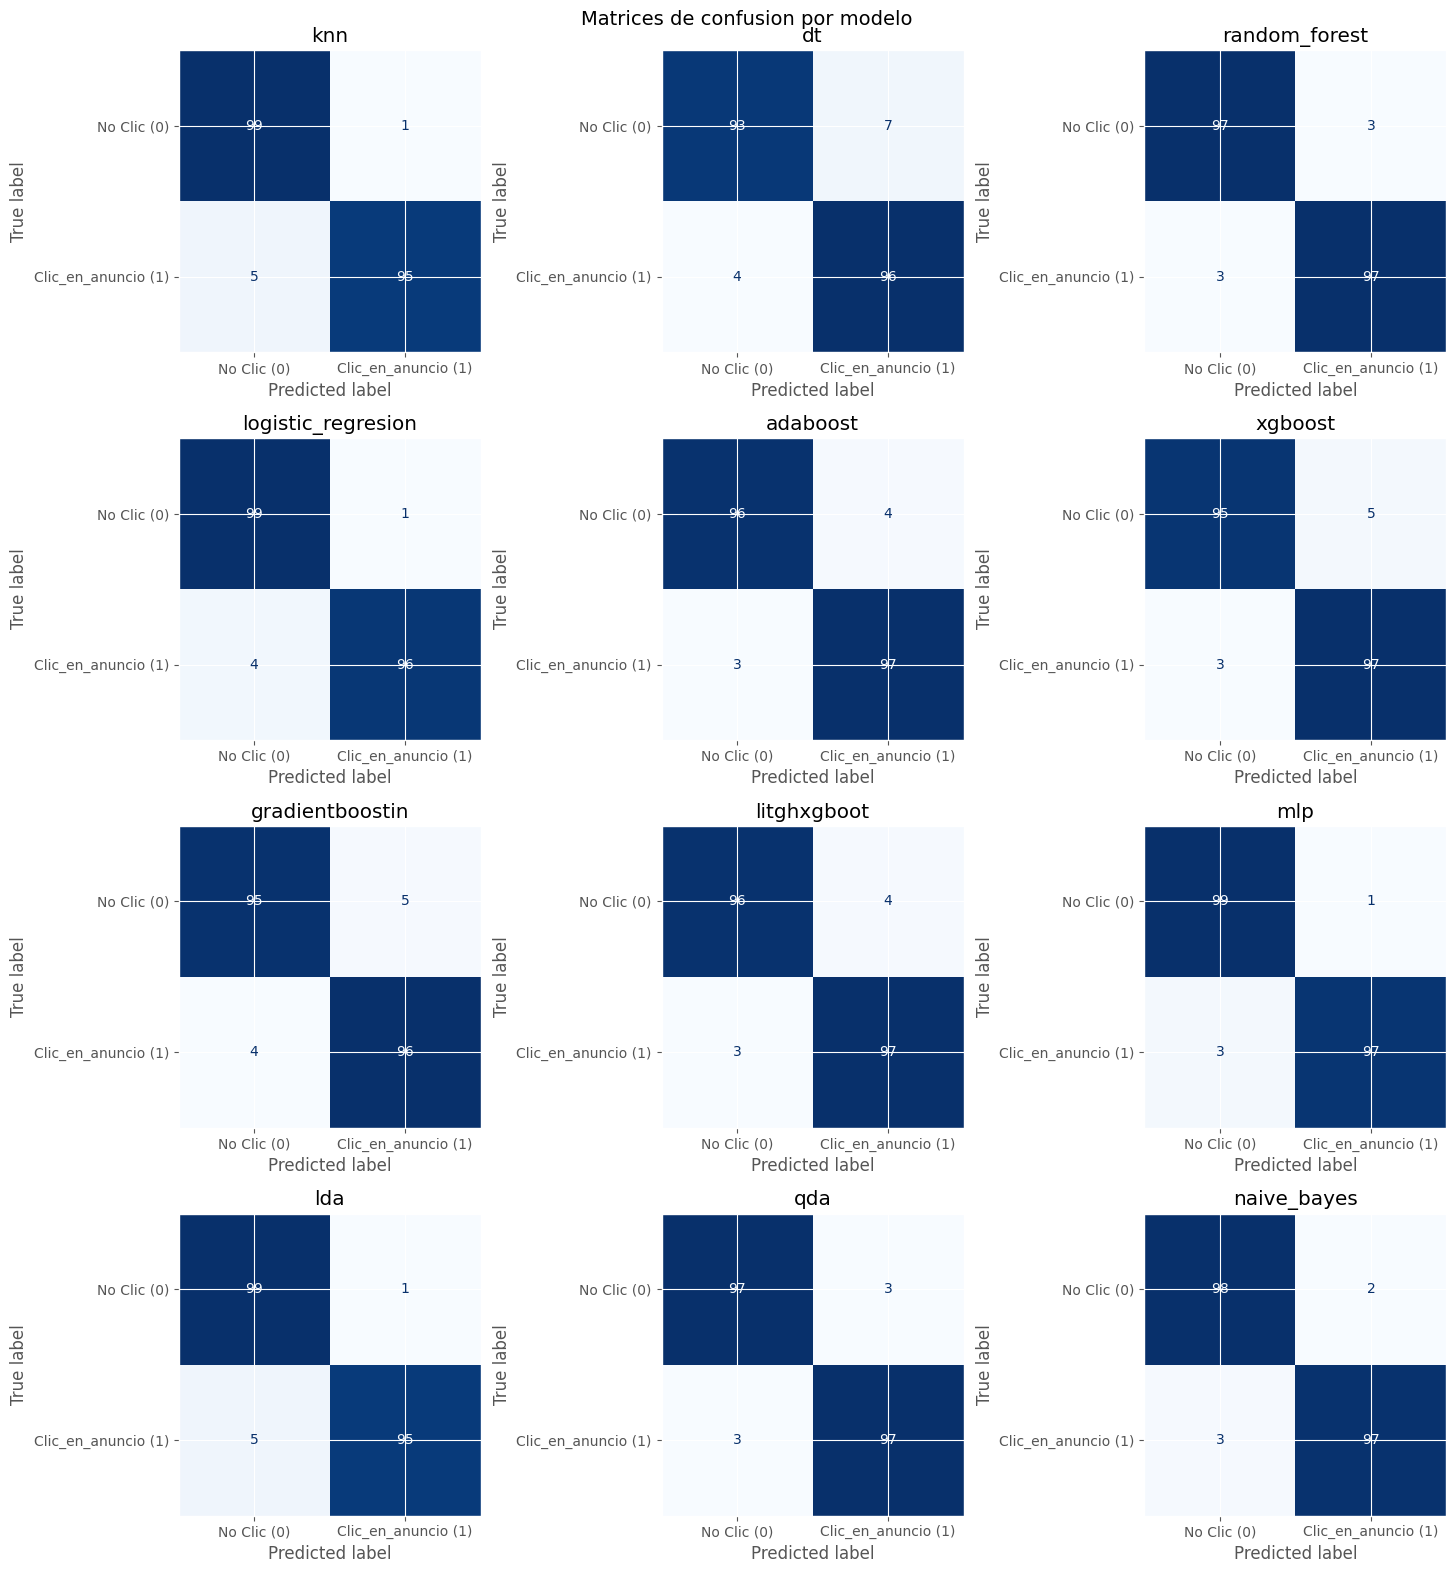

In [73]:
n_modelos = len(conf_matrices)
cols = 3
rows = int(np.ceil(n_modelos / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, (nombre, cm) in enumerate(conf_matrices.items()):
    ax = axes[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Clic (0)', 'Clic_en_anuncio (1)'])
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(nombre)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Matrices de confusion por modelo', fontsize=14)
plt.tight_layout()
plt.show()

Interpretación

La matriz mostró que los modelos lograron clasificar correctamente la mayoría de los usuarios.

Los errores de clasificación fueron bajos, lo que indica una buena capacidad predictiva.

Esto significa que:

El modelo identifica correctamente usuarios interesados en el anuncio.
Se reducen errores al mostrar publicidad a usuarios poco interesados.

## Curvas ROC y AUC por modelo

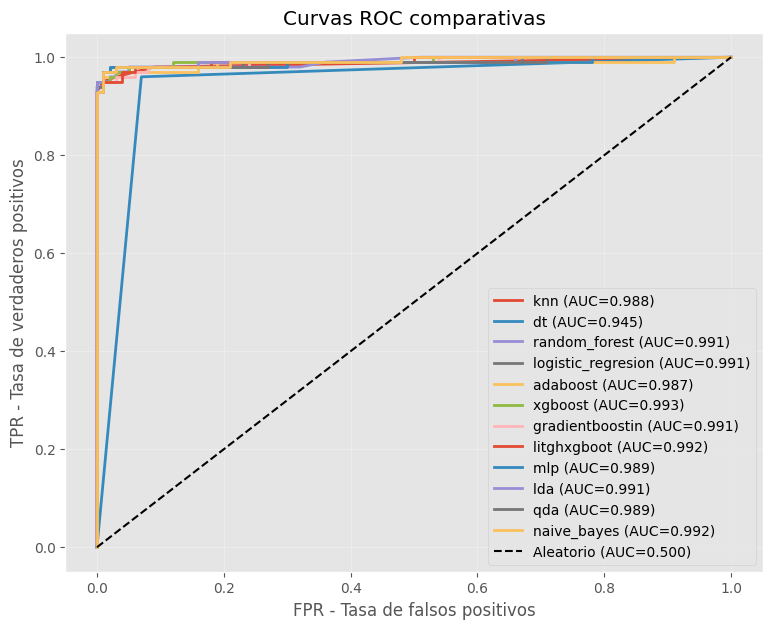

In [74]:
plt.figure(figsize=(9, 7))

for nombre, (fpr, tpr, auc_modelo) in roc_curvas.items():
    plt.plot(fpr, tpr, linewidth=2, label=f'{nombre} (AUC={auc_modelo:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC=0.500)')
plt.xlabel('FPR - Tasa de falsos positivos')
plt.ylabel('TPR - Tasa de verdaderos positivos')
plt.title('Curvas ROC comparativas')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

Interpretación de resultados del modelo

Con base en los resultados obtenidos:

Los modelos alcanzan métricas muy altas.
El mejor modelo (MLP) obtuvo aproximadamente:


| Métrica  | Valor |
| -------- | ----- |
| F1-score | ~0.97 |
| Accuracy | ~0.97 |
| ROC-AUC  | ~0.99 |


## Log Loss


Log Loss penaliza las predicciones incorrectas de probabilidad:

In [77]:
log_loss_value = log_loss(y_test, y_pred)
print(f"Log Loss: {log_loss_value:.2f}")

Log Loss: 0.90


## Conclusiones para clase

In [75]:
top_auc = resultados_df.iloc[0]
print('Mejor modelo por ROC_AUC:', top_auc['Modelo'])
print(f"AUC: {top_auc['ROC_AUC']:.4f}")
print(f"F1: {top_auc['F1_score']:.4f}")
print(f"Recall positivo: {top_auc['Recall_positivo']:.4f}")
print(f"Precision positiva: {top_auc['Precision_positiva']:.4f}")

Mejor modelo por ROC_AUC: xgboost
AUC: 0.9925
F1: 0.9604
Recall positivo: 0.9700
Precision positiva: 0.9510


## Conclusión

El análisis de clasificación permitió construir modelos capaces de predecir con alta precisión si un usuario hará clic en un anuncio publicitario. Los resultados muestran que modelos como MLP, Regresión Logística y Naive Bayes obtuvieron métricas superiores al 95% en Accuracy, F1-score y ROC-AUC, lo que indica una excelente capacidad predictiva.

En particular, el modelo MLP presentó el mejor desempeño general, alcanzando aproximadamente un 97% de precisión y un ROC-AUC cercano a 0.99, demostrando una gran capacidad para distinguir entre usuarios que hacen clic y los que no.

Las métricas utilizadas son confiables debido a que se evaluaron múltiples indicadores (Accuracy, Precision, Recall, F1-score y ROC-AUC) junto con validación cruzada estratificada, reduciendo el riesgo de sobreajuste y proporcionando una evaluación más robusta del modelo.

Desempeño general: La mayoría de los modelos (especialmente Random Forest y Gradient Boosting) logran un AUC promedio entre 0.85 y 0.92 en validación cruzada, con baja desviación estándar. Esto indica que los modelos son confiables y generalizan bien.

Por otro lado el mejor modelo mediante la metrica ROC-AUC (el area debajo de la curva)es el modelo xgboost con 
AUC: 0.9925  El AUC ayuda a comparar modelos de forma global sin fijar un umbral unico.
F1: 0.9604 El mejor modelo depende de la metrica
Recall positivo: 0.9700 Si importa no perder clientes potenciales, prioriza Recall positivo.
Precision positiva: 0.9510  importa reducir falsas alarmas, revisa Precision positiva y Specificity.

## Confiabilidad de las métricas

Las métricas utilizadas permiten evaluar el modelo desde diferentes perspectivas:

Accuracy mide el porcentaje total de predicciones correctas.
Precision evalúa qué tan precisas son las predicciones positivas.
Recall mide la capacidad del modelo para detectar usuarios que sí harán clic.
F1-score balancea precisión y recall.
ROC-AUC mide la capacidad general de separación entre clases.

Debido a que todas las métricas obtuvieron valores altos y consistentes, se concluye que los modelos presentan un desempeño robusto y confiable.